In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/home-data-for-ml-course/sample_submission.csv
/kaggle/input/competitions/home-data-for-ml-course/sample_submission.csv.gz
/kaggle/input/competitions/home-data-for-ml-course/train.csv.gz
/kaggle/input/competitions/home-data-for-ml-course/data_description.txt
/kaggle/input/competitions/home-data-for-ml-course/test.csv.gz
/kaggle/input/competitions/home-data-for-ml-course/train.csv
/kaggle/input/competitions/home-data-for-ml-course/test.csv


In [2]:
train = pd.read_csv('/kaggle/input/competitions/home-data-for-ml-course/train.csv')
test = pd.read_csv('/kaggle/input/competitions/home-data-for-ml-course/test.csv')

print("Train shape", train.shape)
print("Test shape", test.shape)

Train shape (1460, 81)
Test shape (1459, 80)


<bound method NDFrame.describe of 0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64>

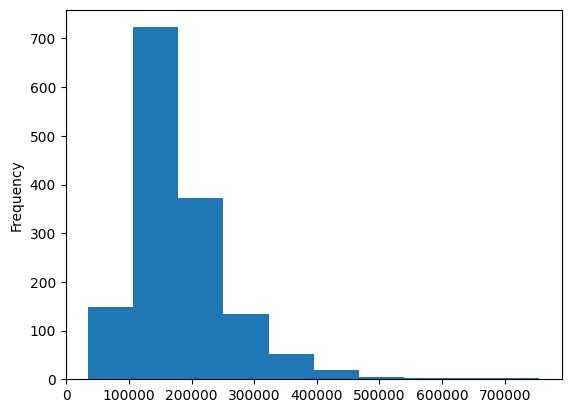

In [3]:
y = train.SalePrice
y.plot(kind = 'hist')
y.describe

# y = train.YearBuilt
# y.plot(kind = 'hist')
# y.describe

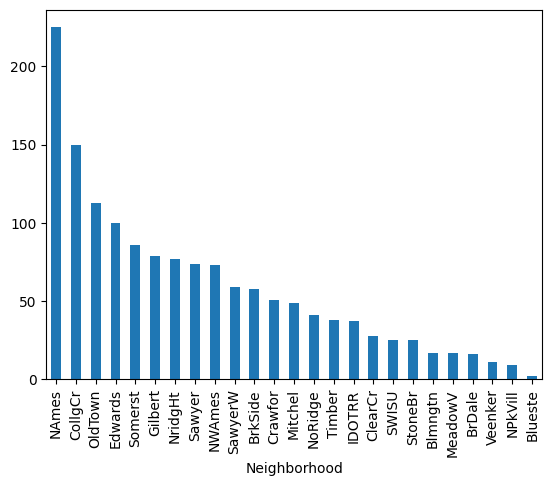

In [4]:
n = train.Neighborhood.value_counts().plot(kind='bar')

In [5]:
features = ["GrLivArea","YearBuilt","OverallQual","BedroomAbvGr","FullBath","LotArea"]

X =  train[features]
X.head()

,GrLivArea,YearBuilt,OverallQual,BedroomAbvGr,FullBath,LotArea
0,1710,2003,7,3,2,8450
1,1262,1976,6,3,2,9600
2,1786,2001,7,3,2,11250
3,1717,1915,7,3,1,9550
4,2198,2000,8,4,2,14260


In [6]:
from sklearn.tree import DecisionTreeRegressor
housing_model = DecisionTreeRegressor(random_state=1)
housing_model.fit(X,y)

print("Making predictions for the following 5 houses:")
print(X.head())

print("The predictions are")
print(housing_model.predict(X.head()))

Making predictions for the following 5 houses:
   GrLivArea  YearBuilt  OverallQual  BedroomAbvGr  FullBath  LotArea
0       1710       2003            7             3         2     8450
1       1262       1976            6             3         2     9600
2       1786       2001            7             3         2    11250
3       1717       1915            7             3         1     9550
4       2198       2000            8             4         2    14260
The predictions are
[208500. 181500. 223500. 140000. 250000.]
